In [1]:
import numpy
import pandas
from src.data_objects import AllData
from src.functions import *
from src.readers import ReadDesign
import os

retrain = False
runchain = False
logTrain = True
scikit = False

ThisData = AllData
ThisData["name"] = "pp-only"

model_par = "input/ppDesign.txt"
outdir = "/data/rjfgroup/rjf01/cameron.parker/tunes/" + ThisData["name"] + "/"
ThisData["Design"] = ReadDesign("/data/rjfgroup/rjf01/cameron.parker/runs/no-part-prop/LHC2760/QVir_Analysis/parameters.txt")

try:
    os.mkdir(outdir)
except:
    print("Output dir exists, will be overwritten")

Output dir exists, will be overwritten


Trimming points and obs ranges

In [2]:
#doesnt converge
#del ThisData["Observables"]["PrPr200"]["kaon-pT-soft"]
del ThisData["Observables"]["PrPr200"]["proton-pT-soft"]
del ThisData["Observables"]["PrPr200"]["pion-pT-hard"]

#del ThisData["Observables"]["PrPr2760"]["charged-pT-soft"]
#del ThisData["Observables"]["PrPr2760"]["charged-pT-hard"]
#del ThisData["Observables"]["PrPr2760"]["pion-pT-hard"]
#del ThisData["Observables"]["PrPr2760"]["kaon-pT-soft"]
#del ThisData["Observables"]["PrPr2760"]["kaon-pT-hard"]
del ThisData["Observables"]["PrPr2760"]["proton-pT-soft"]
del ThisData["Observables"]["PrPr2760"]["proton-pT-hard"]

del ThisData["Observables"]["PrPr13000"]
del ThisData["Observables"]["EpEm91"]

#del ThisData["Observables"]["PrPr200"]
#del ThisData["Observables"]["PrPr2760"]
#del ThisData["Observables"]["PrPr13000"]
#del ThisData["Observables"]["EpEm91"]

ThisData["Observables"]["PrPr200"]["pion-pT-soft"]["cuts"] = []
ThisData["Observables"]["PrPr200"]["kaon-pT-soft"]["cuts"] = []

trimRanges(ThisData)

In [3]:
badpoints = []
trimPoints(badpoints,ThisData)

Making Data pkl for selected observables

In [4]:
buildDataPkl(ThisData, logTrain)
print(ThisData["datapkl"])

Data sets being added to pkl:
PrPr2760charged-pT-soft
PrPr2760charged-pT-hard
PrPr2760pion-pT-soft
PrPr2760pion-pT-hard
PrPr2760kaon-pT-soft
PrPr2760kaon-pT-hard
PrPr2760jets-R2
PrPr2760jets-R3
PrPr2760jets-R4
PrPr200pion-pT-soft
PrPr200kaon-pT-soft
PrPr200jets
/data/rjfgroup/rjf01/cameron.parker/builds/Bayes-Tune/temp-pkls/pp-only/data.pkl


Getting emulators

In [5]:
from src.emulator_BAND import EmulatorBAND

setEmuPaths(ThisData)

if retrain:
    buildObsPkls(ThisData)
    trainEmulators(model_par, ThisData, logTrain, scikit=scikit)
else:
    readEmulators(ThisData)

Running Chain

In [6]:
from src.mcmc import Chain
import os

mcmcpath = "mcmc/" + ThisData["name"] + "-chain.pkl"
mymcmc = Chain(mcmc_path=mcmcpath, expdata_path=ThisData["datapkl"], model_parafile=model_par)
mymcmc.loadEmulator(getEmuPathList(ThisData))

[INFO][mcmc] Initializing MCMC ...
[INFO][mcmc] Final Markov Chain results will be saved in mcmc/pp-only-chain.pkl
[INFO][mcmc] Loading the model parameters space from input/ppDesign.txt ...
[INFO][mcmc] Run MCMC with emcee...
[INFO][mcmc] Loading the experiment data from /data/rjfgroup/rjf01/cameron.parker/builds/Bayes-Tune/temp-pkls/pp-only/data.pkl ...
[INFO][mcmc] Experimental dataset size: 227
Emulators being loaded:
/data/rjfgroup/rjf01/cameron.parker/builds/Bayes-Tune/emulators/pp-only/PrPr2760charged-pT-soft-emulator.sav
/data/rjfgroup/rjf01/cameron.parker/builds/Bayes-Tune/emulators/pp-only/PrPr2760charged-pT-hard-emulator.sav
/data/rjfgroup/rjf01/cameron.parker/builds/Bayes-Tune/emulators/pp-only/PrPr2760pion-pT-soft-emulator.sav
/data/rjfgroup/rjf01/cameron.parker/builds/Bayes-Tune/emulators/pp-only/PrPr2760pion-pT-hard-emulator.sav
/data/rjfgroup/rjf01/cameron.parker/builds/Bayes-Tune/emulators/pp-only/PrPr2760kaon-pT-soft-emulator.sav
/data/rjfgroup/rjf01/cameron.parker/bu

In [7]:
print(mymcmc.max)

[0.5   5.    4.    1.    1.    0.4   0.082]


In [8]:
os.environ["OMP_NUM_THREADS"] = "20"
# may have to: export RDMAV_FORK_SAFE=1 before running the code

n_effective=16000
n_active=8000
n_prior=16000
sample="tpcn"
n_max_steps=500
random_state=43

n_total = 100000
n_evidence = 0

pool = 20

if runchain:
    sampler = mymcmc.run_pocoMC(n_effective=n_effective, n_active=n_active,
                            n_prior=n_prior, sample=sample,
                            n_max_steps=n_max_steps, random_state=random_state,
                            n_total=n_total, n_evidence=n_evidence, pool=pool)

Corner Plot

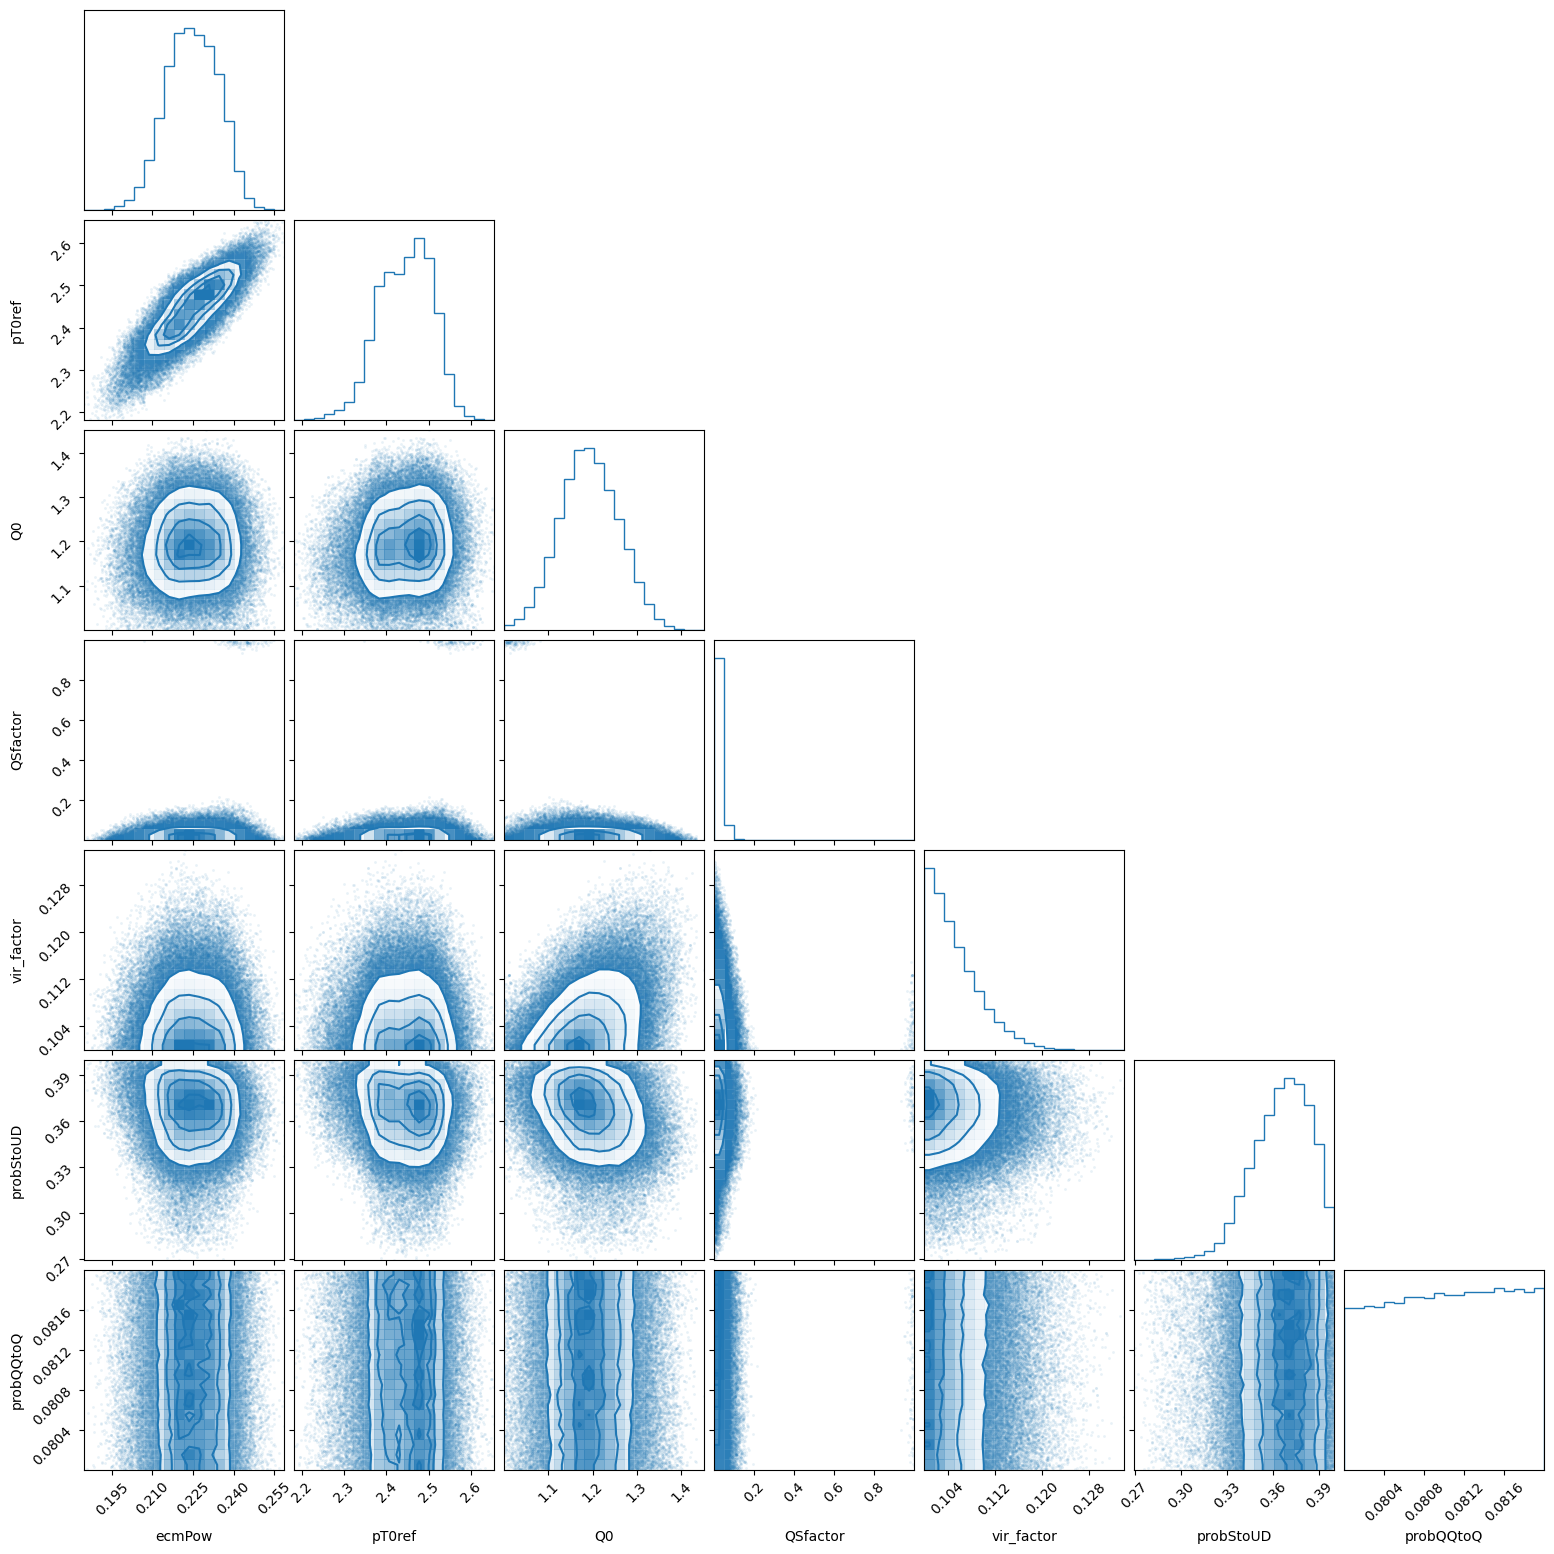

In [9]:
import pickle
import corner
import matplotlib.pyplot as plt
import numpy as np
        
with open(mcmcpath, 'rb') as pf:
        data = pickle.load(pf)

labels = mymcmc.label

fig = corner.corner(data['chain'], weights=data['weights'], labels=labels, color="C0")
plt.show()

chain_params(data,ThisData["Design"]["Parameter"],outdir)

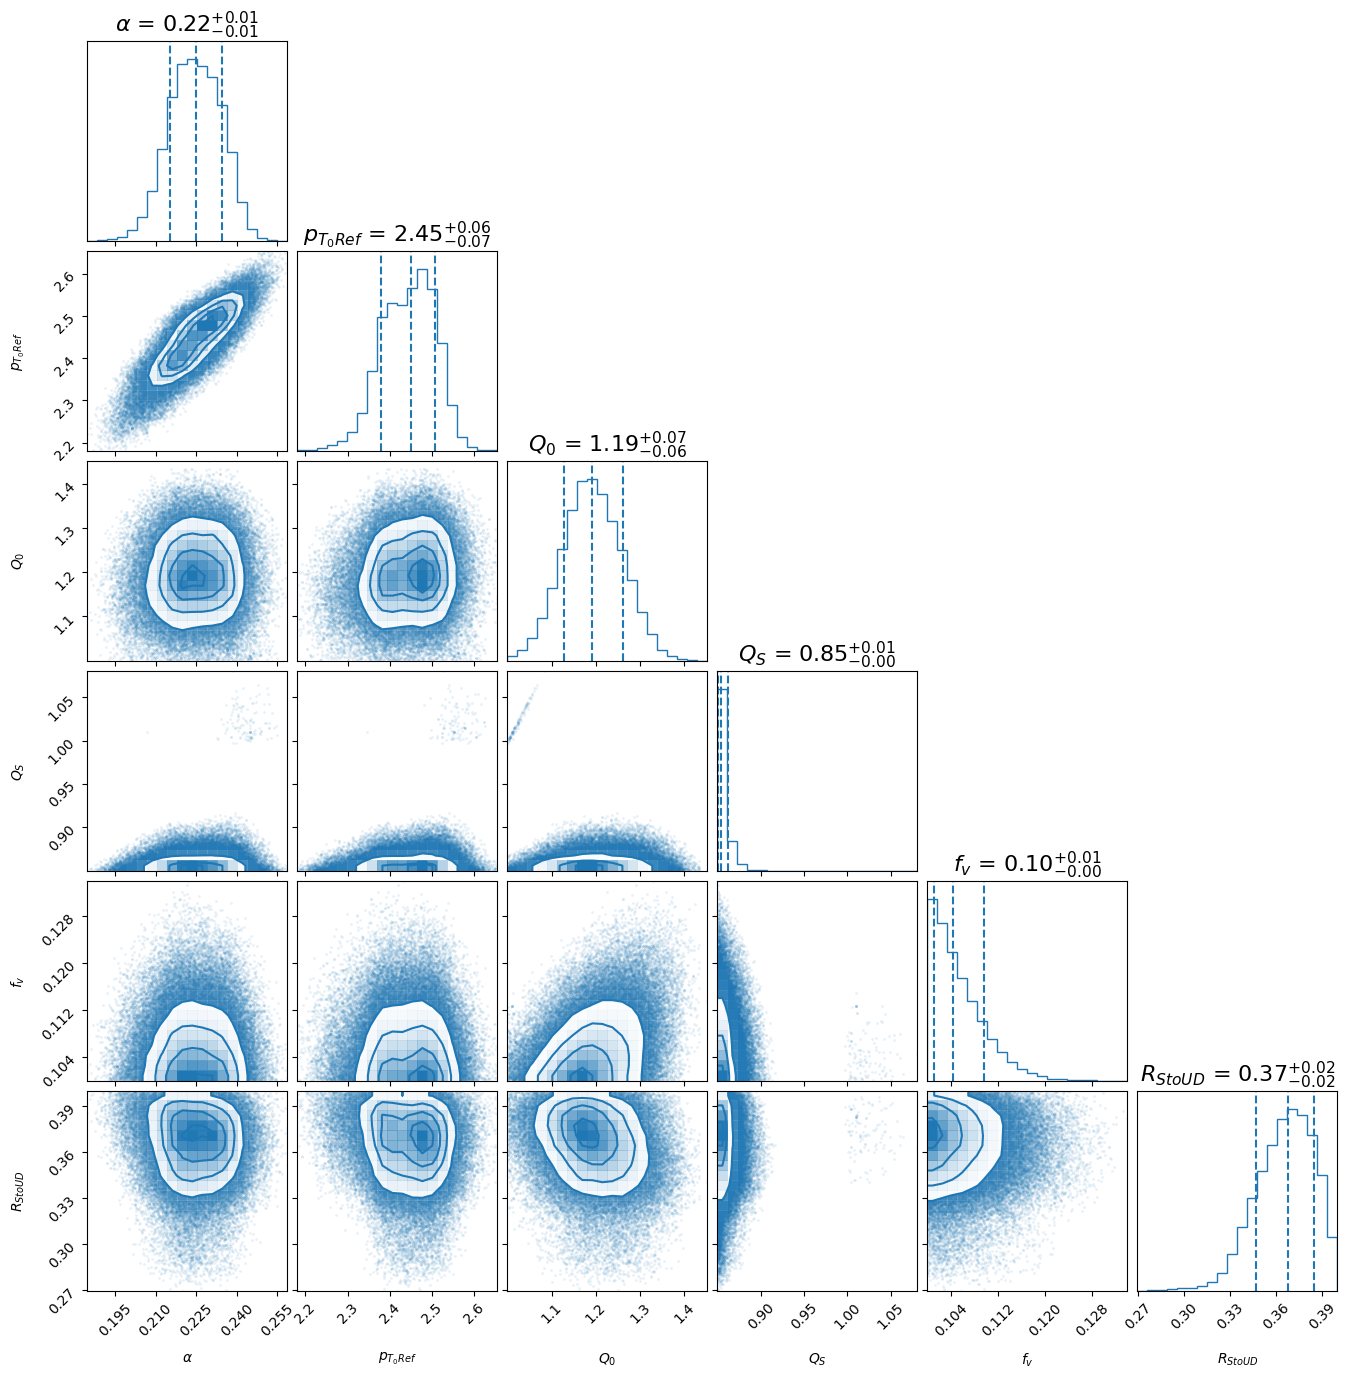

In [10]:
TransformedSamples = np.copy(data['chain'])
TransformedSamples[:,0] = data['chain'][:,0]
TransformedSamples[:,1] = data['chain'][:,1]
TransformedSamples[:,2] = data['chain'][:,2]
TransformedSamples[:,3] = (2*0.4+0.05) + (data['chain'][:,2]-(2*0.4+0.05))*data['chain'][:,3]
TransformedSamples[:,4] = data['chain'][:,4]
TransformedSamples[:,5] = data['chain'][:,5]
TransformedSamples[:,6] = data['chain'][:,6]

labels = [r"$\alpha$",
          r"$p_{T_0Ref}$",
          r"$Q_0$",
          r"$Q_S$",
          r"$f_v$",
          r"$R_{StoUD}$"]

fig = corner.corner(TransformedSamples[:,:6], 
                weights=data['weights'], 
                labels=labels, 
                quantiles=[0.16, 0.5, 0.84],
                show_titles=True,
                title_kwargs={"fontsize": 16},
                color="C0")
plt.show()
fig.savefig(outdir+'Corner.pdf', dpi = 192)

Priors

Making Priors...


/data/rjfgroup/rjf01/cameron.parker/builds/Bayes-Tune/src/functions.py:316: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro" (-> color='r'). The keyword argument will take precedence.
  axes[0][i].errorbar(DX, DY, yerr = DE, fmt='ro', label="Measurements", color='black')
/data/rjfgroup/rjf01/cameron.parker/builds/Bayes-Tune/src/functions.py:317: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "b-" (-> linestyle='-'). The keyword argument will take precedence.
  axes[1][i].plot(DX, 1+(DE/DY), 'b-', linestyle = '--', color='red')
/data/rjfgroup/rjf01/cameron.parker/builds/Bayes-Tune/src/functions.py:317: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b-" (-> color='b'). The keyword argument will take precedence.
  axes[1][i].plot(DX, 1+(DE/DY), 'b-', linestyle = '--', color='red')
/data/rjfgroup/rjf01/cameron.parker/builds/Bayes-Tune/src/fun

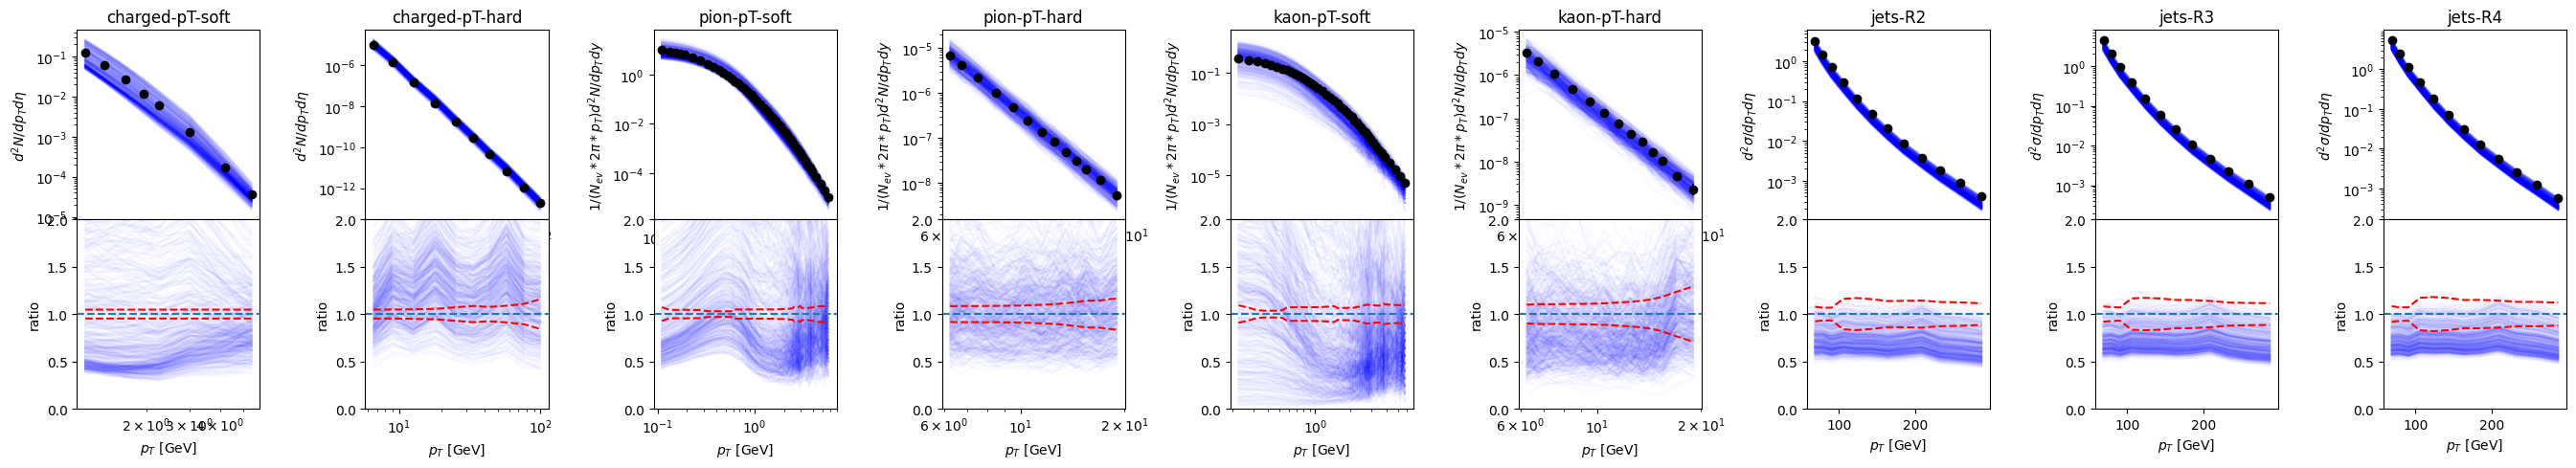

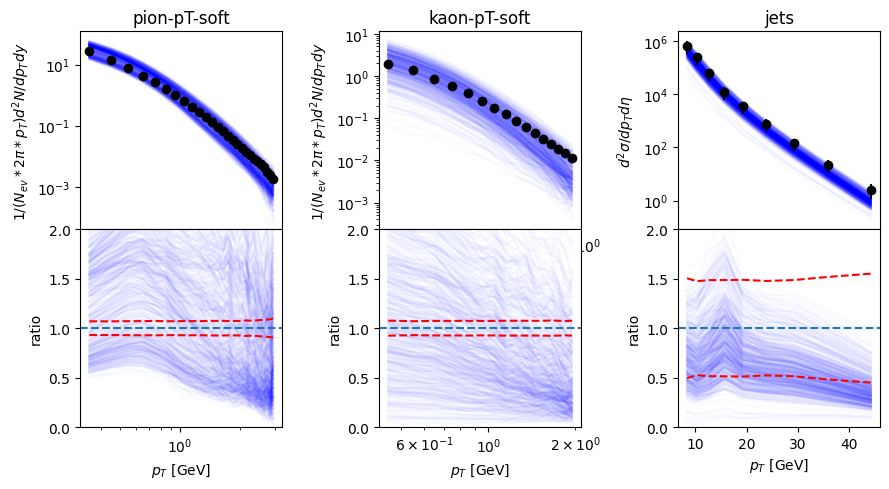

In [11]:
makeplot(ThisData, "Priors", outdir, logTrain=logTrain)

Posteriors

Making Posteriors...


/data/rjfgroup/rjf01/cameron.parker/builds/Bayes-Tune/src/functions.py:316: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro" (-> color='r'). The keyword argument will take precedence.
  axes[0][i].errorbar(DX, DY, yerr = DE, fmt='ro', label="Measurements", color='black')
/data/rjfgroup/rjf01/cameron.parker/builds/Bayes-Tune/src/functions.py:317: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "b-" (-> linestyle='-'). The keyword argument will take precedence.
  axes[1][i].plot(DX, 1+(DE/DY), 'b-', linestyle = '--', color='red')
/data/rjfgroup/rjf01/cameron.parker/builds/Bayes-Tune/src/functions.py:317: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b-" (-> color='b'). The keyword argument will take precedence.
  axes[1][i].plot(DX, 1+(DE/DY), 'b-', linestyle = '--', color='red')
/data/rjfgroup/rjf01/cameron.parker/builds/Bayes-Tune/src/fun

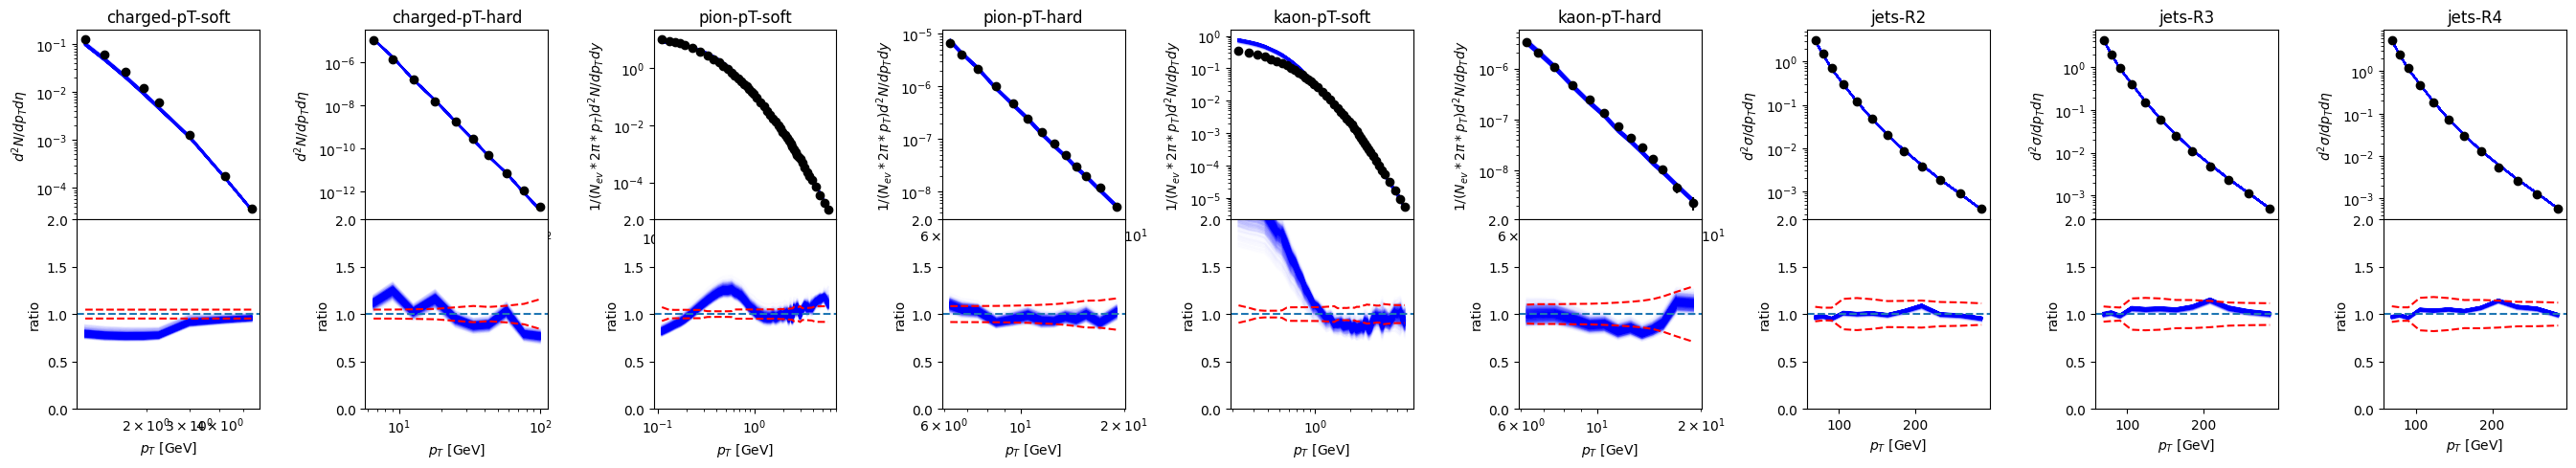

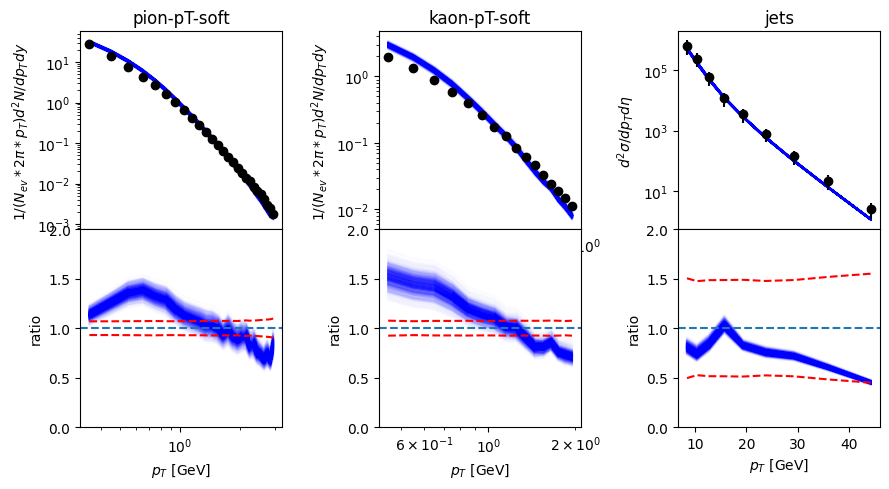

In [12]:
makeplot(ThisData, "Posteriors", outdir, samples=data["chain"], logTrain=logTrain, scikit=scikit)

Validation

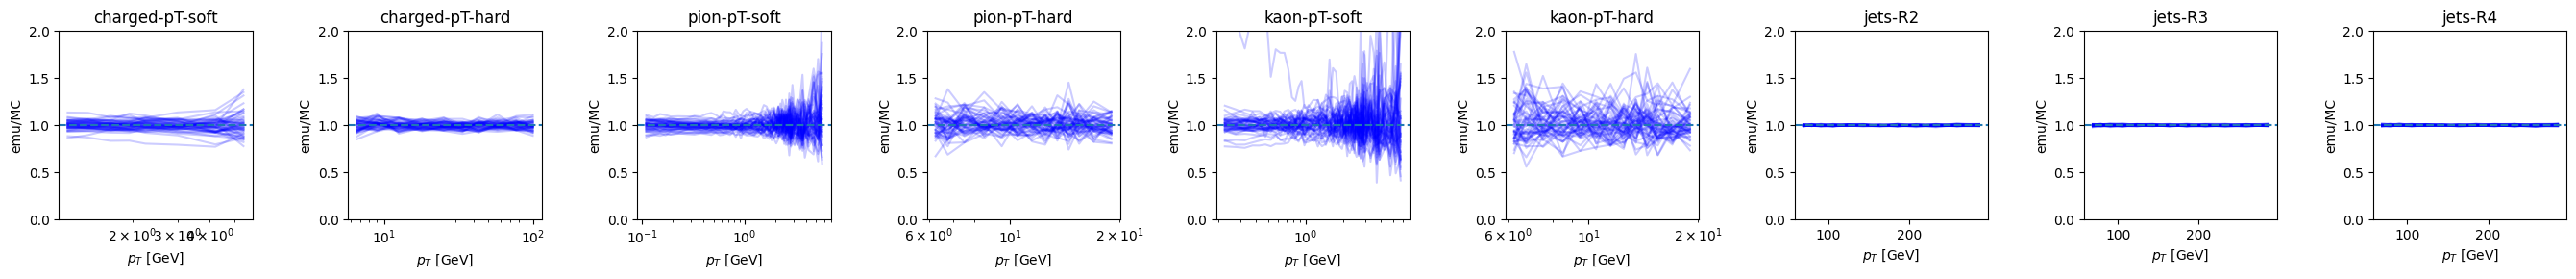

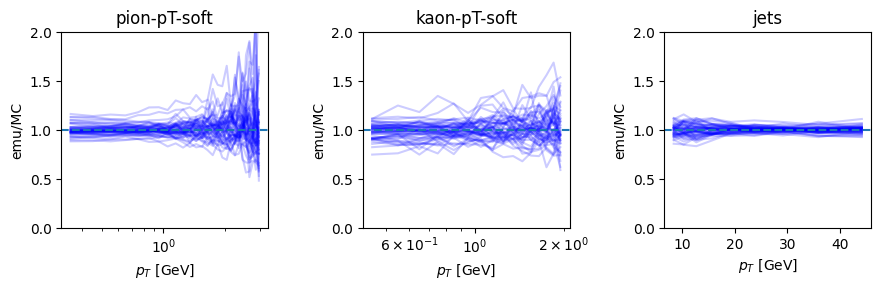

In [13]:
from src.data_objects import valData

valData["Design"] = ReadDesign("/data/rjfgroup/rjf01/cameron.parker/runs/no-part-prop-val/LHC2760/QVir_Analysis/parameters.txt")
updateCuts(ThisData,valData)
trimRanges(valData)
validationPlots(valData, ThisData, outdir, logTrain=logTrain, scikit=scikit)

Honesty Plots

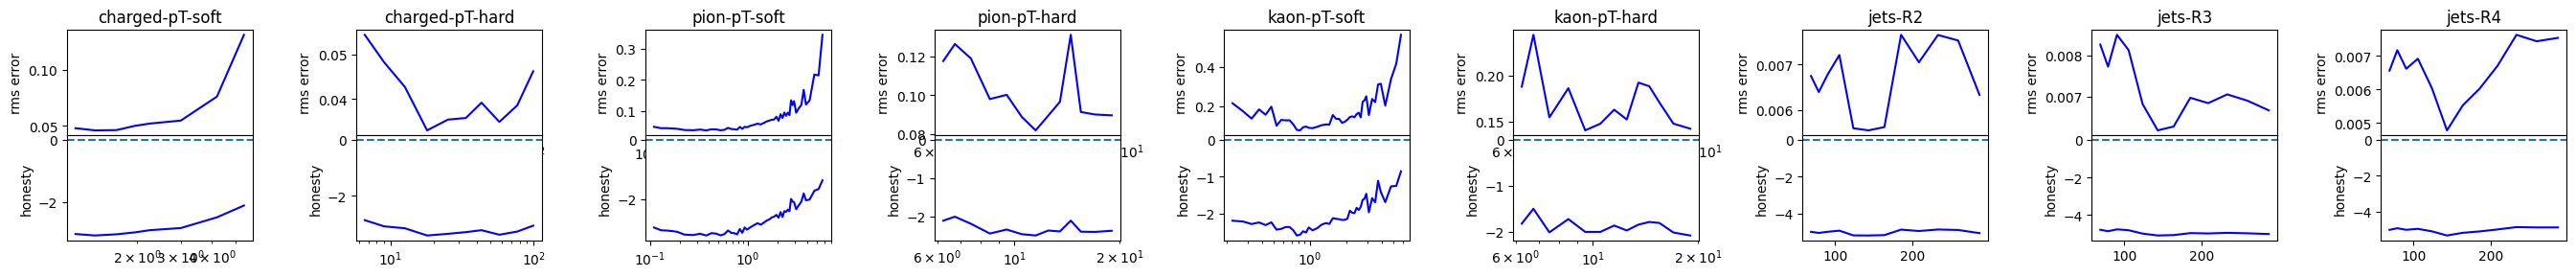

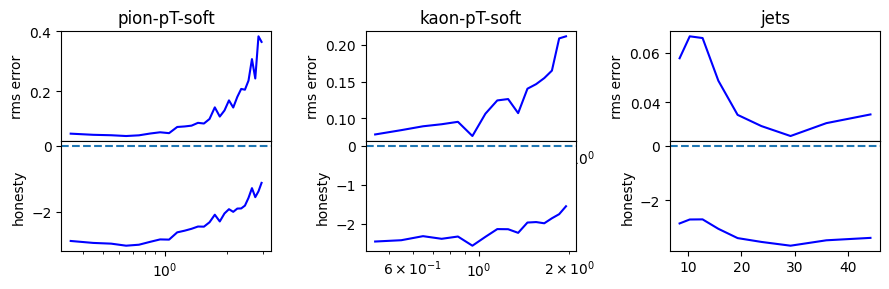

In [14]:
ErrorHonestyPlots(valData,ThisData,outdir,logTrain=logTrain,scikit=scikit)

Closure Tests

Running closure test...
Adding PrPr2760charged-pT-soft to closure data
Adding PrPr2760charged-pT-hard to closure data
Adding PrPr2760pion-pT-soft to closure data
Adding PrPr2760pion-pT-hard to closure data
Adding PrPr2760kaon-pT-soft to closure data
Adding PrPr2760kaon-pT-hard to closure data
Adding PrPr2760jets-R2 to closure data
Adding PrPr2760jets-R3 to closure data
Adding PrPr2760jets-R4 to closure data
Adding PrPr200pion-pT-soft to closure data
Adding PrPr200kaon-pT-soft to closure data
Adding PrPr200jets to closure data
[INFO][mcmc] Initializing MCMC ...
[INFO][mcmc] Final Markov Chain results will be saved in mcmc/pp-only-closure.pkl
[INFO][mcmc] Loading the model parameters space from input/ppDesign.txt ...
[INFO][mcmc] Run MCMC with emcee...
[INFO][mcmc] Loading the experiment data from /data/rjfgroup/rjf01/cameron.parker/builds/Bayes-Tune/temp-pkls/pp-only/closure.pkl ...
[INFO][mcmc] Experimental dataset size: 227
Emulators being loaded:
/data/rjfgroup/rjf01/cameron.parker/b

Iter: 40it [2:06:35, 189.89s/it, beta=1, calls=330000, ESS=24666, logZ=527, logP=551, acc=0.716, steps=4, eff=1]             

[INFO][mcmc] Generate the posterior samples ...


[INFO][mcmc] Generate the evidence ...
Log evidence:  527.232868976488
Log evidence error:  None
[INFO][mcmc] Writing pocoMC chains to file...


/home/rjfgroup/cameron.parker/.local/lib/python3.8/site-packages/scipy/optimize/_differentialevolution.py:382: UserWarning: differential_evolution: the 'vectorized' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,


differential_evolution step 1: f(x)= -240.755
differential_evolution step 2: f(x)= -240.755
differential_evolution step 3: f(x)= -395.685
differential_evolution step 4: f(x)= -395.685
differential_evolution step 5: f(x)= -486.189
differential_evolution step 6: f(x)= -512.989
differential_evolution step 7: f(x)= -531.646
differential_evolution step 8: f(x)= -531.646
differential_evolution step 9: f(x)= -531.646
differential_evolution step 10: f(x)= -531.646
differential_evolution step 11: f(x)= -531.646
differential_evolution step 12: f(x)= -535.825
differential_evolution step 13: f(x)= -535.825
differential_evolution step 14: f(x)= -539.526
differential_evolution step 15: f(x)= -541.876
differential_evolution step 16: f(x)= -545.589
differential_evolution step 17: f(x)= -545.589
differential_evolution step 18: f(x)= -545.589
differential_evolution step 19: f(x)= -545.589
differential_evolution step 20: f(x)= -547.974
differential_evolution step 21: f(x)= -547.974
differential_evolution

/home/rjfgroup/cameron.parker/.local/lib/python3.8/site-packages/scipy/optimize/_numdiff.py:576: RuntimeWarning: invalid value encountered in subtract
  df = fun(x) - f0


[0.44949016 2.95620716 3.70963591 0.61279379 0.46711517 0.13517968
 0.08      ]
[WARNING][core] Too few points to create valid contours
[WARNING][core] Too few points to create valid contours
[WARNING][core] Too few points to create valid contours
[WARNING][core] Too few points to create valid contours
[WARNING][core] Too few points to create valid contours
[WARNING][core] Too few points to create valid contours
[WARNING][core] Too few points to create valid contours
[WARNING][core] Too few points to create valid contours
[WARNING][core] Too few points to create valid contours
[WARNING][core] Too few points to create valid contours
[WARNING][core] Too few points to create valid contours
[WARNING][core] Too few points to create valid contours
[WARNING][core] Too few points to create valid contours
[WARNING][core] Too few points to create valid contours
Parameter: calculated vs actual
ecmPow: 0.449 vs  0.4420699780298048 (0.15, 0.5)
pT0ref: 2.956 vs  2.9787294219469977 (1.0, 5.0)
Q0: 3.7

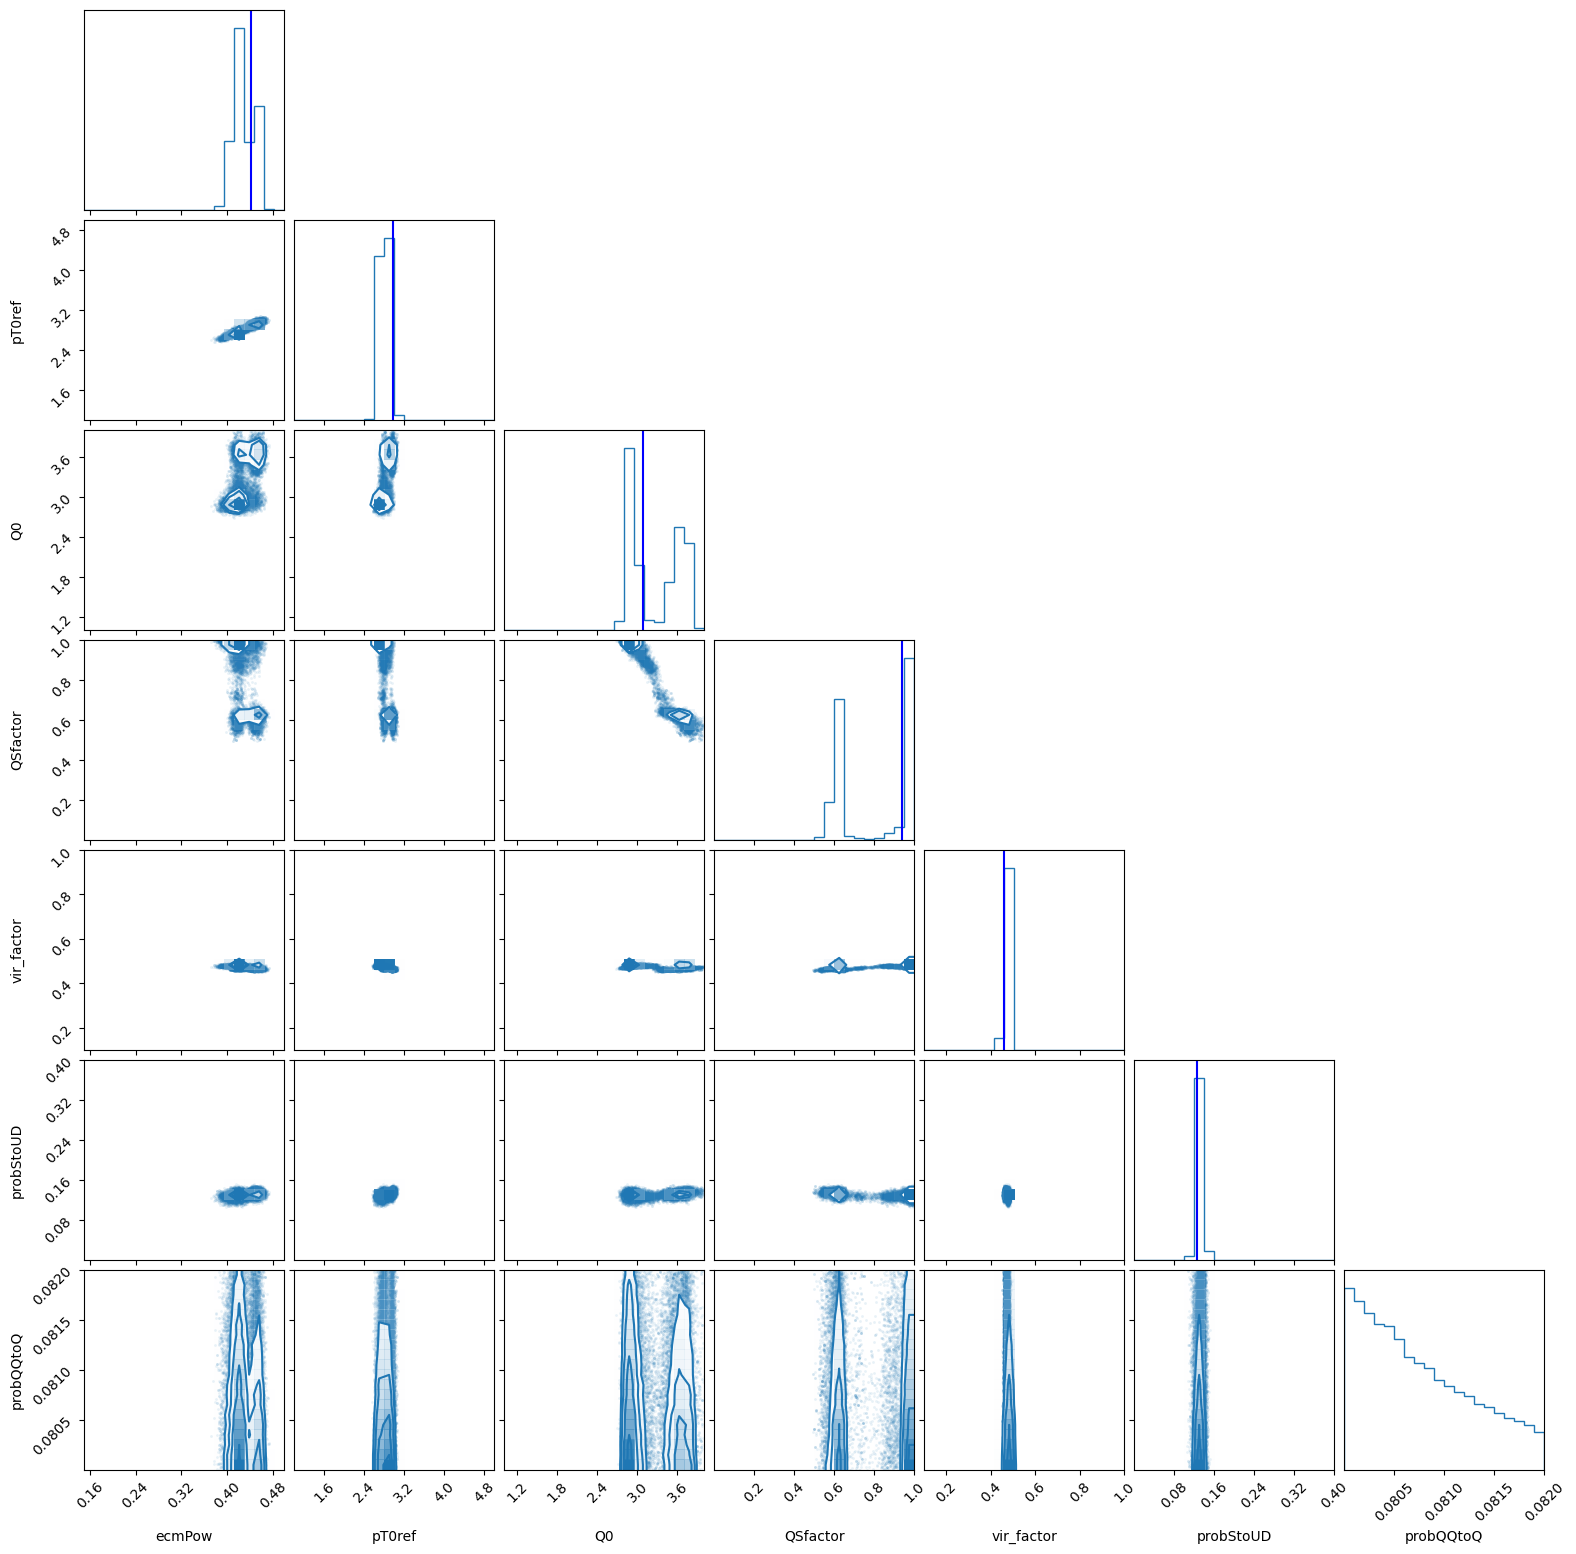

In [15]:
closureTest(ThisData, valData, outdir, model_par, runchain=True, logTrain=logTrain)